# **Support Vector Machines**

**Support Vector Machines** (SVMs) were first introduced in the early 1990s by Vladimir Vapnik and his colleagues at AT&T Bell Laboratories. They are rooted in statistical learning theory, which Vapnik and Alexey Chervonenkis had developed decades earlier. The key innovation of SVMs was the use of the “maximum margin” principle to find the optimal separating hyperplane between classes, improving generalization performance. Later extensions, such as the kernel trick, allowed SVMs to handle nonlinear data, making them one of the most powerful and widely used machine learning methods in the late 1990s and early 2000s.

The key idea of a **Support Vector Machine** is to find the **optimal separating hyperplane** that acts as the linear boundary between samples from different classes. For a binary classification problem, data points on one side of the hyperplane belong to one class, while those on the other side belong to the second class. In cases involving more than two classes, SVMs typically use strategies such as one-vs-one or one-vs-rest to construct multiple binary classifiers that together handle multi-class classification.

## **Few words on Logistic Regression**

In logistic regression, the classifier learns a linear score $z = w^\top x + b$ and maps it to a probability using the sigmoid function:

$$
P(y=1 \mid x)=\sigma(z)=\frac{1}{1+e^{-z}}
$$

The decision boundary is where the predicted probability is exactly $0.5$, which happens where the linear score is zero:

$$
w^\top x + b = 0
$$

In 2D this boundary is a line; in higher dimensions it is a **hyperplane**. Therefore, logistic regression can be explained as finding a separating hyperplane, but unlike an SVM, it does so by modeling class probabilities rather than by maximizing the geometric margin.

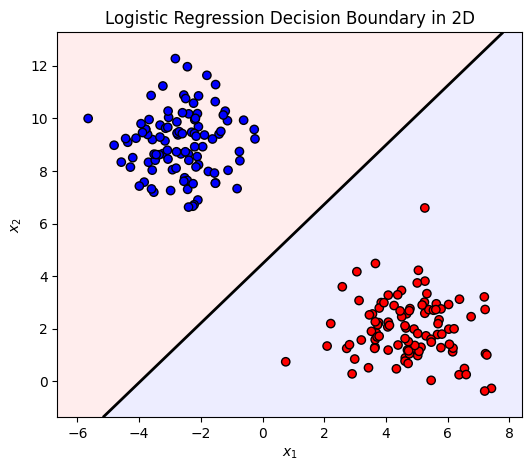

Decision boundary: 1.09 * x_1 + -0.96 * x_2 + 4.32 = 0


In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=200, centers=2, cluster_std=1.2, random_state=42)

clf = LogisticRegression().fit(X, y)

xx, yy = np.meshgrid(
    np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 300),
    np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 300)
)

Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, Z, levels=[-1e9, 0, 1e9], colors=["#FFCCCC", "#CCCCFF"], alpha=0.35)
plt.contour(xx, yy, Z, levels=[0], colors="black", linewidths=2)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="bwr", edgecolor="k")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Logistic Regression Decision Boundary in 2D")
plt.show()

w = clf.coef_[0]
b = clf.intercept_[0]
print(f"Decision boundary: {w[0]:.2f} * x_1 + {w[1]:.2f} * x_2 + {b:.2f} = 0")

## **Geometrical Intuition**

Suppose we have two classes of samples—red circles and green diamonds—each represented by two-dimensional features. As shown below, these two classes are perfectly **linearly** separable by some single straight line.
  

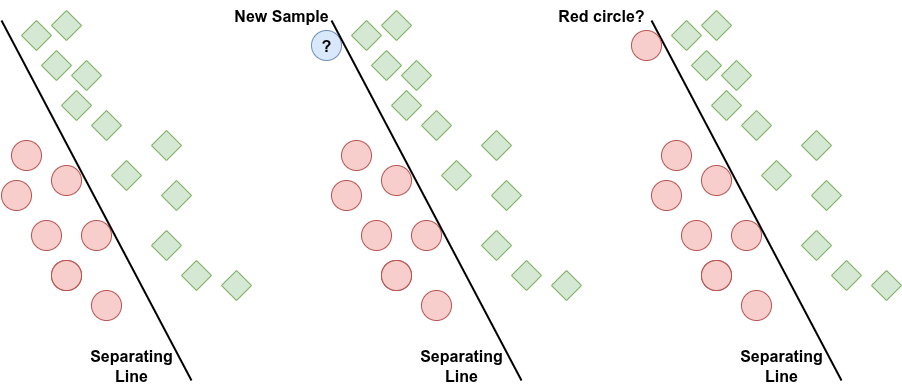

Now suppose a new sample (a blue circle) arrives. Based on the separating line we previously defined, this sample would be classified as belonging to the red circle class. However, the visualization suggests otherwise, the sample appears to be closer to the green diamond class. How confident can we be in this classification? And is there a way to improve our decision boundary?

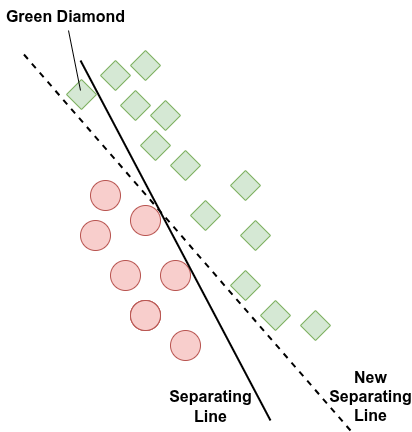

It turns out that there are actually **infinitely many** lines that can separate our dataset, as long as the classes are linearly separable. However, even with a valid separating line, we may still misclassify new samples. Moreover, in real-world problems, we often deal with feature spaces of much higher dimensionality, where visualization is no longer possible. Therefore, we need a **principled and robust** approach to identify the best possible separating boundary. Vladimir Vapnik addressed this challenge by introducing a method to determine the **optimal hyperplane** from an infinite number of possible ones.

Vapnik’s idea was both simple and elegant: to identify the hyperplane that lies exactly midway between the **closest samples** (called **support vectors**) of the two classes. Formally, this corresponds to finding the hyperplane that **maximizes the margin**, i.e., the perpendicular distance between the decision boundary and the nearest data points from each class. To construct this margin, two parallel hyperplanes (dashed lines) are defined, each passing through the closest samples of one class, while the optimal separating hyperplane lies precisely at the center. Importantly, no other data points may fall within this margin region, ensuring maximum separation and robustness against misclassification.

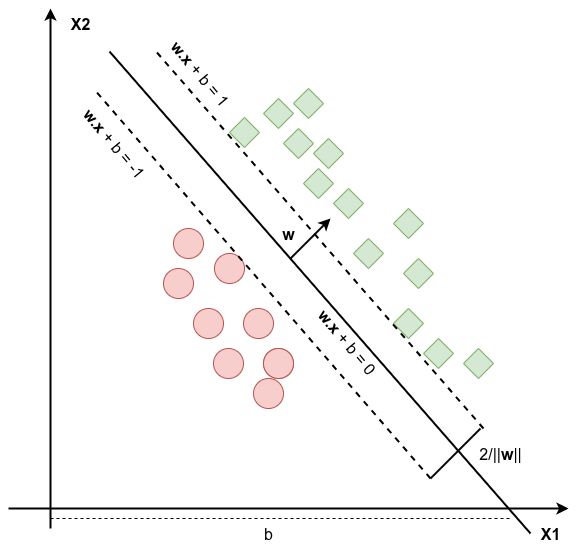

This idea was implemented by B. Boser in 1991 at At&T Bell Labs. By finding this optimal hyperplane, the classifier achieves a greater ability to generalize, i.e., it is more likely to correctly assign new, unseen samples to the appropriate class (e.g., circle or triangle) than a hyperplane determined by simpler and naive methods.

What we also see here is the weight vector $\mathbf{w}$, which defines the orientation of the hyperplane (our separating line in the plot). This vector is **perpendicular** (normal) to the hyperplane and determines the position and slope of the decision boundary. The margin width between the two supporting hyperplanes is given by $\frac{2}{\textbf{||w||}}$. The equation for the separtating line is

$$\mathbf{w\cdot x} + b = 0$$

and the support vectors satisfy

$$\mathbf{w\cdot x} + b = \pm 1.$$

The term $\mathbf{w\cdot x}$ represents the projection of a sample $\mathbf{x}$ onto the normal vector $\mathbf{w}$. The scalar $b$ is the bias (offset), which shifts the hyperplane (separating line) away from the origin. The sign of

$$
\text{sign}(\mathbf{w} \cdot \mathbf{x} + b) =
\begin{cases}
+1, & \text{if } \mathbf{x} \text{ belongs to the positive class (or red circles)} \\[2mm]
-1, & \text{if } \mathbf{x} \text{ belongs to the negative class (or green diamonds).}
\end{cases}
$$

In our example there are a few samples which define support vectors, but in general case the number of such samples can be different and strictly depends on training dataset.

To understand the essence of these vector equations let's recap the line equation.

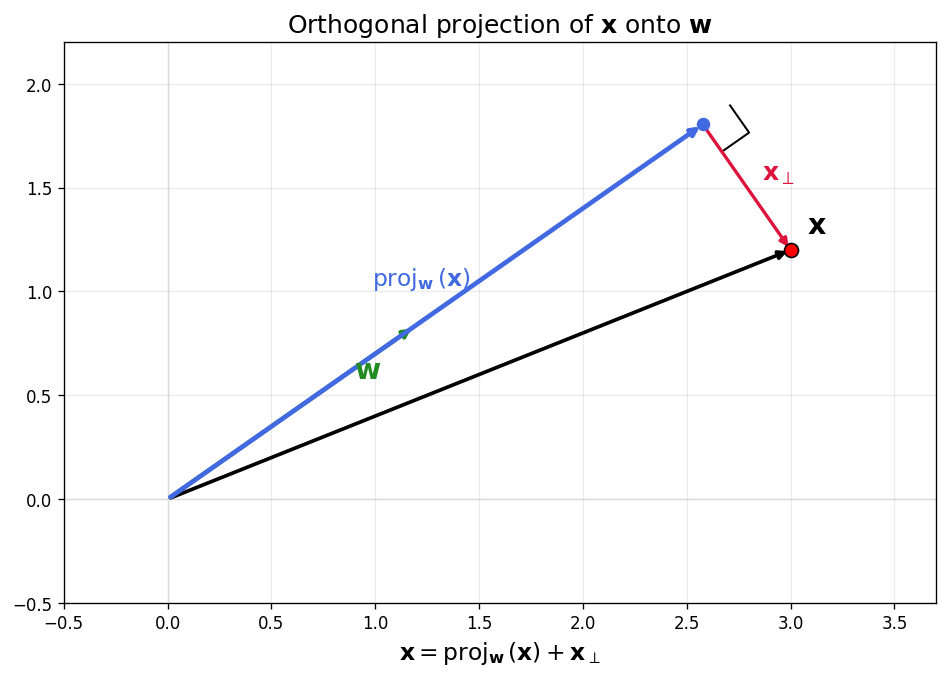

x · ŵ = 3.146
w · x = 3.840
||w|| = 1.221
||w|| · (x · ŵ) = 3.840


In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt

w = np.array([1.0, 0.7])
x = np.array([3.0, 1.2])

nw = np.linalg.norm(w)
w_hat = w / nw

proj = (x @ w_hat) * w_hat
x_perp = x - proj


def arrow(ax, p, q, color, lw=2):
    ax.annotate(
        '',
        xy=q,
        xytext=p,
        arrowprops=dict(
            arrowstyle='-|>',
            color=color,
            lw=lw
        )
    )


def right_angle(ax, corner, u1, u2, size=0.16):
    points = np.array([
        corner + size * u1,
        corner + size * (u1 + u2),
        corner + size * u2
    ])
    ax.plot(
        points[:, 0],
        points[:, 1],
        color='black',
        lw=1.2
    )


fig, ax = plt.subplots(figsize=(8, 6), dpi=120)

arrow(ax, np.zeros(2), x, 'black', 2.2)

arrow(ax, np.zeros(2), 1.45 * w_hat, 'forestgreen', 2.5)

arrow(ax, np.zeros(2), proj, 'royalblue', 2.8)

arrow(ax, proj, x, 'crimson', 2.0)

right_angle(
    ax,
    proj,
    w_hat,
    x_perp / np.linalg.norm(x_perp)
)

ax.scatter(
    *x,
    s=70,
    color='red',
    edgecolor='black',
    zorder=5
)

ax.scatter(
    *proj,
    s=50,
    color='royalblue',
    zorder=5
)

ax.text(
    *(x + [0.08, 0.08]),
    r'$\mathbf{x}$',
    fontsize=17
)

ax.text(
    *(1 * w_hat + [0.08, 0.01]),
    r'$\mathbf{w}$',
    color='forestgreen',
    fontsize=17
)

ax.text(
    *(0.35 * proj + [0.08, 0.4]),
    r'$\operatorname{proj}_{\mathbf{w}}(\mathbf{x})$',
    color='royalblue',
    fontsize=14
)

ax.text(
    *(proj + 0.48 * x_perp + [0.08, 0.02]),
    r'$\mathbf{x}_{\perp}$',
    color='crimson',
    fontsize=15
)

ax.set_title(
    r'Orthogonal projection of $\mathbf{x}$ onto $\mathbf{w}$',
    fontsize=15
)

ax.set_xlim(-0.5, 3.7)
ax.set_ylim(-0.5, 2.2)

ax.set_aspect('equal')
ax.grid(alpha=0.25)

ax.axhline(0, color='0.85', lw=0.8)
ax.axvline(0, color='0.85', lw=0.8)

ax.text(
    0.5,
    -0.10,
    r'$\mathbf{x}=\operatorname{proj}_{\mathbf{w}}(\mathbf{x})+\mathbf{x}_{\perp}$',
    transform=ax.transAxes,
    ha='center',
    fontsize=14
)

plt.tight_layout()
plt.show()

print(f'x · ŵ = {x @ w_hat:.3f}')
print(f'w · x = {x @ w:.3f}')
print(f'||w|| = {nw:.3f}')
print(f'||w|| · (x · ŵ) = {nw * (x @ w_hat):.3f}')

## **Intuition Behind Support Vectors in 2D Space**

**Defining the Vector Equation of a Line in 2D**


To define a line in 2D space, we start with two logical requirements:

1. $\textbf{Direction:}$ The line must have a direction, represented by a direction vector
$$
\mathbf{v} =
\begin{bmatrix}
v_1 \\[4pt]
v_2
\end{bmatrix}.
$$

2. $\textbf{Anchor point:}$ The line must pass through a fixed point (the anchor point)
$$
\mathbf{z}_0 =
\begin{bmatrix}
x_0 \\[4pt]
y_0
\end{bmatrix}.
$$

$\textbf{Vector equation of the line:}$

Combining these two conditions, any point $\mathbf{x}$ on the line can be expressed as
$$
\mathbf{x} = \mathbf{z}_0 + t\mathbf{v}, \quad t \in \mathbb{R}.
$$

In component form:
$$
\begin{bmatrix}
x \\[4pt]
y
\end{bmatrix}
=
\begin{bmatrix}
x_0 \\[4pt]
y_0
\end{bmatrix}
+
t
\begin{bmatrix}
v_1 \\[4pt]
v_2
\end{bmatrix}.
$$


$\textbf{Parametric form:}$

From the vector equation, we can write the line as two scalar equations:
$$
\begin{cases}
x = x_0 + t v_1, \\[4pt]
y = y_0 + t v_2,
\end{cases}
\quad t \in \mathbb{R}.
$$

This form expresses each coordinate as a function of the parameter $ t $.


$\textbf{Geometric interpretation:}$

This equation means that we start at the anchor point $\mathbf{z}_0$ and move along the direction of $\mathbf{v}$, scaling it by a real number $t$:

$$
\begin{cases}
t > 0 & \text{moves in the direction of } \mathbf{v}, \\[4pt]
t < 0 & \text{moves in the opposite direction}, \\[4pt]
t = 0 & \text{gives the anchor point itself.}
\end{cases}
$$

So geometrically, the line is obtained by stretching the direction vector infinitely in both directions through the point $\mathbf{z}_0$.

$$
\boxed{
\mathbf{x} = \mathbf{z}_0 + t\mathbf{v}, \quad t \in \mathbb{R}
}
$$

This is the standard **vector form** of a line in 2D. The same reasoning generalizes from a line in 2D to a **hyperplane in $R^N$ space**.


Let's think of a line as the $\textbf{separating boundary}$ between two classes.
This is exactly what an SVM does in 2D space.


To define the **margin**, that is, the free-of-samples tunnel between the closest points (support vectors) of the two classes, we introduce a vector
$$
\mathbf{w} = (w_1, w_2)
$$
that is **perpendicular** to the separating line.  
The vector $ \mathbf{w} $ determines the line's orientation and helps measure the margin width.


By definition, for any point $ \mathbf{x} $ lying on the separating line, the displacement vector
$$
\mathbf{x} - \mathbf{z}_0 = (x - x_0, \, y - y_0)
$$
must be orthogonal to $ \mathbf{w} $.
Hence, their dot product must be zero:

$$
\mathbf{w} \cdot (\mathbf{x} - \mathbf{z}_0) = 0.
$$



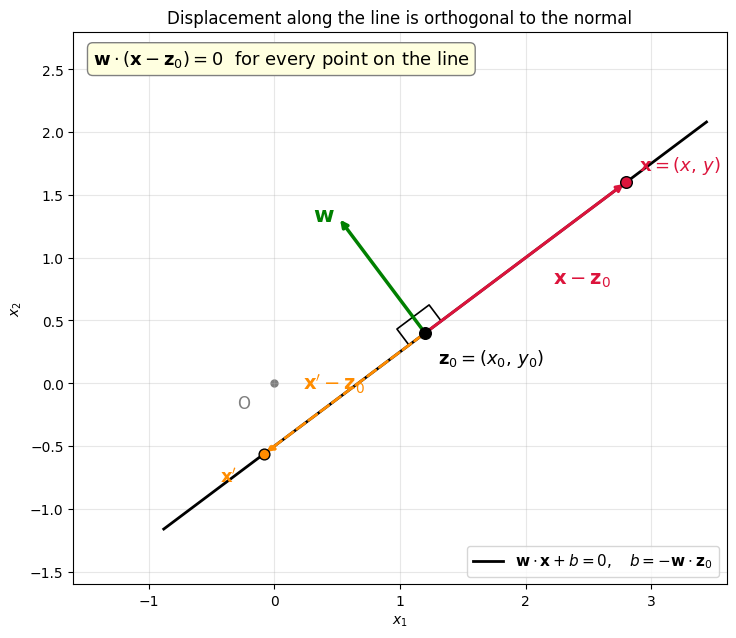

w·(x1 - z0) = 3.3306690738754696e-16
w·(x2 - z0) = 1.1102230246251565e-16
b = -w·z0  = 0.3999999999999999


In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt

z0 = np.array([1.2, 0.4])
v_hat = np.array([0.8, 0.6])
w = np.array([-v_hat[1], v_hat[0]])
b = -w @ z0
x1 = z0 + 2.0 * v_hat
x2 = z0 - 1.6 * v_hat

def arrow(ax, p, q, **kw):
    ax.annotate('', xy=q, xytext=p, arrowprops=dict(arrowstyle='-|>', **kw))

def right_angle(ax, corner, u1, u2, size=0.16, **kw):
    pts = np.array([corner + size*u1, corner + size*(u1+u2), corner + size*u2])
    ax.plot(pts[:, 0], pts[:, 1], **kw)

fig, ax = plt.subplots(figsize=(7.5, 6.5))

t = np.linspace(-2.6, 2.8, 2)
pts = z0 + np.outer(t, v_hat)
ax.plot(pts[:, 0], pts[:, 1], 'k-', lw=2,
        label=r'$\mathbf{w}\cdot\mathbf{x}+b=0,\quad b=-\mathbf{w}\cdot\mathbf{z}_0$')

arrow(ax, z0, z0 + 1.15*w, color='green', lw=2.5)
ax.text(*(z0 + 1.25*w - 0.18*v_hat), r'$\mathbf{w}$', color='green', fontsize=16)

arrow(ax, z0, x1, color='crimson', lw=2.2)
ax.text(*(z0 + 1.05*v_hat - 0.30*w), r'$\mathbf{x}-\mathbf{z}_0$', color='crimson', fontsize=14)
arrow(ax, z0, x2, color='darkorange', lw=2.0, ls='--')
ax.text(*(z0 - 1.05*v_hat + 0.22*w), r"$\mathbf{x}'-\mathbf{z}_0$", color='darkorange', fontsize=14)

right_angle(ax, z0, w,  v_hat, color='k', lw=1.2)
right_angle(ax, z0, w, -v_hat, color='k', lw=1.2)

ax.scatter(*z0, s=70, color='k', zorder=5)
ax.text(*(z0 + np.array([0.10, -0.24])), r'$\mathbf{z}_0=(x_0,\,y_0)$', fontsize=13)
ax.scatter(*x1, s=70, color='crimson', edgecolor='k', zorder=5)
ax.text(*(x1 + np.array([0.10, 0.10])), r'$\mathbf{x}=(x,\,y)$', color='crimson', fontsize=13)
ax.scatter(*x2, s=60, color='darkorange', edgecolor='k', zorder=5)
ax.text(*(x2 + np.array([-0.35, -0.22])), r"$\mathbf{x}'$", color='darkorange', fontsize=13)

ax.scatter(0, 0, s=25, color='gray')
ax.text(-0.30, -0.20, 'O', color='gray', fontsize=12)

ax.text(0.03, 0.97, r'$\mathbf{w}\cdot(\mathbf{x}-\mathbf{z}_0)=0$  for every point on the line',
        transform=ax.transAxes, va='top', fontsize=13,
        bbox=dict(boxstyle='round', fc='lightyellow', ec='gray'))

ax.set_title('Displacement along the line is orthogonal to the normal')
ax.set_xlim(-1.6, 3.6); ax.set_ylim(-1.6, 2.8)
ax.set_aspect('equal'); ax.grid(alpha=0.3)
ax.legend(loc='lower right', fontsize=11)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
plt.tight_layout()
plt.show()

print('w·(x1 - z0) =', w @ (x1 - z0))
print('w·(x2 - z0) =', w @ (x2 - z0))
print('b = -w·z0  =', b)

Expanding this expression:

$$
w_1(x - x_0) + w_2(y - y_0) = 0,
$$
$$
w_1x + w_2y + (-w_1x_0 - w_2y_0) = 0.
$$

We define
$$
b = - (w_1x_0 + w_2y_0),
$$
which is called the $\textbf{bias term}$ (or intercept).
It controls how far the line is shifted from the origin.

Thus, the equation of the separating line becomes

$$
\boxed{\mathbf{w} \cdot \mathbf{x} + b = 0.}
$$


The two parallel lines that form the **margins** (the boundaries of the tunnel)
are defined as:

$$
\mathbf{w} \cdot \mathbf{x} + b = 1,
$$
and
$$
\mathbf{w} \cdot \mathbf{x} + b = -1.
$$


**The scaling / normalization**:


The equations above contain a subtle but crucial action:
we can *rescale* the vector $\mathbf{w}$ and the bias $b$ by the same positive constant
without changing the position of the separating line.
That is, for any scalar $ k > 0 $:

$$
(\mathbf{w}, b) \quad \text{and} \quad (k\mathbf{w}, kb)
$$

define the **same** separating boundary
because both satisfy $ k(\mathbf{w} \cdot \mathbf{x} + b) = 0 $.


Therefore, we are free to choose the scaling of $\mathbf{w}$ and $b$
such that the closest points (the support vectors) satisfy

$$
\mathbf{w} \cdot \mathbf{x}_i + b = \pm 1.
$$

### **Distance between support vectors**


To get the distance between support vectors which are parallel we have to remind the dot product formula:

$$\textbf{u} \cdot \textbf{v} = ||\textbf{u}|| \cdot ||\textbf{v}||cos\alpha. $$


To find the projection of vector $\textbf{u}$ onto vector $\textbf{v}$ we can use the property of a right triangle

$$cos\alpha = \frac{proj_vu}{||\textbf{u}||} $$

Since

$$proj_vu = ||\textbf{u}|| cos\alpha$$

then

$$\frac{\textbf{u} \cdot \textbf{v}}{||\textbf{v}||} = proj_vu.$$

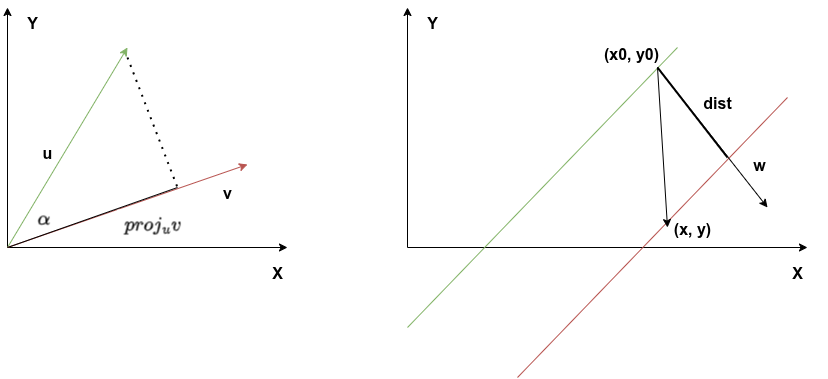

Because the distance between two parallel lines is simply the $\textbf{projection}$ of the vector from a point on one line to a point on the other line
onto the perpendicular vector $\mathbf{w}$, we can use the same geometric principles as before.

Let the first line be defined as
$$
\mathbf{w} \cdot \mathbf{x} + b = 0,
$$
and the second as
$$
\mathbf{w} \cdot \mathbf{x} + b = 1.
$$


If $ \mathbf{x}_0 = (x_0, y_0) $ lies on the first line,
and $ \mathbf{x} = (x, y) $ lies on the second,
then the vector between them is

$$
\mathbf{x} - \mathbf{x}_0 = (x - x_0,\, y - y_0).
$$

The $\textbf{distance}$ between the lines equals the projection of this vector
onto $ \mathbf{w} $:

$$
\text{dist} = \frac{|(\mathbf{x} - \mathbf{x}_0) \cdot \mathbf{w}|}{\|\mathbf{w}\|}.
$$

Substituting in the line equations:

$$
\mathbf{w} \cdot \mathbf{x}_0 + b = 0 \quad \Rightarrow \quad \mathbf{w} \cdot \mathbf{x}_0 = -b,
$$
and
$$
\mathbf{w} \cdot \mathbf{x} + b = 1 \quad \Rightarrow \quad \mathbf{w} \cdot \mathbf{x} = 1 - b.
$$

Therefore,
$$
(\mathbf{x} - \mathbf{x}_0) \cdot \mathbf{w}
= (\mathbf{w} \cdot \mathbf{x}) - (\mathbf{w} \cdot \mathbf{x}_0)
= (1 - b) - (-b) = 1.
$$

So the distance between the two parallel lines is

$$
\text{dist} = \frac{1}{\|\mathbf{w}\|}.
$$

Because the margin consists of two such distances (on both sides of the separating line),
the total margin width is

$$
\boxed{\text{Margin} = \frac{2}{\|\mathbf{w}\|}}.
$$


Hence, the goal of the SVM is to find the vector $ \mathbf{w} $ that
$\textbf{maximizes the margin}$, subject to the constraint

$$
\mathbf{w} \cdot \mathbf{x}_i + b = \pm 1,
$$

for the closest data points (the support vectors).


Maximizing the margin
$$
\max_{\mathbf{w},b} \; \frac{2}{\|\mathbf{w}\|}
$$
is equivalent to minimizing the norm of $ \mathbf{w} $.

For convenience, we instead minimize one-half of the squared norm:

$$
\boxed{\min_{\mathbf{w},b} \; \frac{1}{2}\|\mathbf{w}\|^2}.
$$


$
\textbf{Why minimize } \tfrac{1}{2}\|\mathbf{w}\|^2 \textbf{ instead of } \|\mathbf{w}\|?
$

1. The square function is $\textbf{monotonic}$ for positive values,
   so minimizing $ \|\mathbf{w}\|^2 $ is equivalent to minimizing $ \|\mathbf{w}\| $.  
   It does not change the solution.

2. Here, squaring makes the optimization function **differentiable everywhere** and much easier to handle analytically and computationally.

3. The factor $ \tfrac{1}{2} $ is included purely for mathematical convenience, when differentiating, it cancels the exponent, giving cleaner gradient expressions:
   $$
   \nabla_{\mathbf{w}} \tfrac{1}{2}\|\mathbf{w}\|^2 = \mathbf{w}.
   $$

Thus, minimizing $ \tfrac{1}{2}\|\mathbf{w}\|^2 $
is a smooth, convex optimization problem that directly corresponds to
$\textbf{maximizing the geometric margin}$.

## **Hard Margin Classifier**


Although we have formulated the Support Vector Machine (SVM) problem in a two-dimensional space for visualization and intuition, **all the underlying geometric and mathematical principles extend naturally to higher-dimensional spaces**.


In higher dimensions (i.e., in $ \mathbb{R}^3 $ and beyond):

- The separating **line** in 2D becomes a **plane** in 3D,  
  and more generally, a hyperplane in $ \mathbb{R}^n $.  
- The normal vector $ \mathbf{w} $ still defines the orientation of this hyperplane.  
- The scalar $ b $ (the bias term) continues to control its offset from the origin.  
- The margin between the two supporting hyperplanes remains inversely proportional to the norm of the normal vector:
  $$
  \text{Margin} = \frac{2}{\|\mathbf{w}\|}.
  $$


Thus, the **SVM optimization problem** retains exactly the same form in any dimension:

$$
\begin{aligned}
\min_{\mathbf{w}, b} \quad & \frac{1}{2}\|\mathbf{w}\|^2 \\
\text{subject to} \quad & y_i (\mathbf{w} \cdot \mathbf{x}_i + b) \ge 1, \quad \forall i.
\end{aligned}
$$


This version of SVM is called the **hard-margin classifier**.


In this formulation:

- We assume that the data are $\textbf{perfectly linearly separable}$,  
  meaning there exists a hyperplane that separates all samples of different classes without error.  
- Every sample lies either outside or exactly on the margin boundaries:
  $$
  \mathbf{w} \cdot \mathbf{x}_i + b =
  \begin{cases}
  \ge +1, & \text{for class } y_i = +1, \\[4pt]
  \le -1, & \text{for class } y_i = -1.
  \end{cases}
  $$
- The support vectors are those samples for which the equality holds
  (i.e., $ y_i(\mathbf{w} \cdot \mathbf{x}_i + b) = 1 $).



Thus, the hard-margin SVM finds the $\textbf{maximum-margin separating hyperplane}$ in any dimension, under the assumption that no classification errors are allowed.


Later, this concept is generalized to the $\textbf{soft-margin SVM}$, which introduces slack variables to handle noisy or non-separable data, while preserving the same geometric principles.

### **Optimization Explanation (Optional)**

This problem is mathematically called a *constrained optimization* problem. We will not delve deeply into the details, but it can be effectively solved using **Lagrange multipliers**.

To handle the inequality constraints, we introduce multipliers $\alpha_i \ge 0$, one for each training sample. This gives the **Lagrangian**:

$$
L(\mathbf{w},b,\boldsymbol{\alpha}) = \frac{1}{2}\|\mathbf{w}\|^2 - \sum_{i=1}^{N} \alpha_i \big(y_i (\mathbf{w}^\top \mathbf{x}_i + b) - 1\big),
$$

where the "variables" of the optimization are:

- $\mathbf{w}$ (vector),
- $b$ (scalar),
- $\boldsymbol{\alpha} = (\alpha_1, \dots, \alpha_N)$ (vector of multipliers).

In this Lagrangian formulation, it initially appears to be a three-way optimization problem. However, it is actually a **minimax problem**. The procedure is not “optimize everything at once.” Instead:

- In the **primal form**:

$$
\min_{\mathbf{w},b} \max_{\boldsymbol{\alpha} \ge 0} L(\mathbf{w},b,\boldsymbol{\alpha})
$$

- In the **dual form**:

$$
\max_{\boldsymbol{\alpha} \ge 0} \min_{\mathbf{w},b} L(\mathbf{w},b,\boldsymbol{\alpha})
$$

The procedure is as follows: minimize with respect to $\mathbf{w}$ and $b$, then substitute the results back into $L$ to obtain the **dual problem** purely in terms of $\boldsymbol{\alpha}$.

From the **stationarity conditions**:

$$
\frac{\partial L}{\partial \mathbf{w}} = 0 \quad \Rightarrow \quad \mathbf{w} = \sum_{i=1}^{N} \alpha_i y_i \mathbf{x}_i,
$$

$$
\frac{\partial L}{\partial b} = 0 \quad \Rightarrow \quad \sum_{i=1}^{N} \alpha_i y_i = 0.
$$

Substituting these back into the Lagrangian gives the **dual problem**:

$$
\max_{\boldsymbol{\alpha} \ge 0} \sum_{i=1}^{N} \alpha_i - \frac{1}{2} \sum_{i=1}^{N} \sum_{j=1}^{N} \alpha_i \alpha_j y_i y_j \mathbf{x}_i^\top \mathbf{x}_j
$$

subject to:

$$
\sum_{i=1}^{N} \alpha_i y_i = 0.
$$


### **SVM Decision Function for Classifying New Samples**


After solving the SVM optimization problem, we obtain either:

1. The $\textbf{primal solution}$: the optimal weight vector $\mathbf{w}$ and bias  $b$, or  
2. The $\textbf{dual solution}$: the Lagrange multipliers $\alpha_i$ corresponding to the support vectors $\mathbf{x}_i$.



For a new sample $\mathbf{x}_{\text{new}}$, the classification is performed using the $\textbf{decision function}$:

$$
f(\mathbf{x}_{\text{new}}) = \text{sign}\big(\mathbf{w} \cdot \mathbf{x}_{\text{new}} + b\big),
$$

where $\text{sign}(\cdot)$ outputs $+1$ or $-1$ depending on the class.


$\textbf{Using the Lagrangian Multipliers:}$

The weight vector $\mathbf{w}$ is obtained based on constrained optimization problem and equals:

$$
\mathbf{w} = \sum_{i \in \text{SV}} \alpha_i y_i \mathbf{x}_i.
$$

The bias $b$ is:

$$
b = y_i - \mathbf{w}^\top \mathbf{x}_i.
$$

If one has the several such support vectors, it’s numerically more stable to take the average:

$$
b = \frac{1}{N_{\text{SV}}} \sum_{i \in \text{SV}} \left( y_i - \mathbf{w}^\top \mathbf{x}_i \right).
$$

The decision function is expressed as:

$$
f(\mathbf{x}_{\text{new}}) = \text{sign} \left( \sum_{i \in \text{SV}} \alpha_i y_i \mathbf{x}_i \cdot \mathbf{x}_{\text{new}} + b \right),
$$

where:

- $\mathbf{x}_i$ are the support vectors,  
- $y_i \in \{+1, -1\}$ are their labels,  
- $\alpha_i$ are the dual variables from the optimization, and  
- $b$ is the bias term.

This is often called the decision function or projection function, it gives the (scaled) signed distance to the separating plane.


$\textbf{Key points:}$

1. Only the $\textbf{support vectors}$ contribute to the decision function.  
2. The classification boundary (hyperplane) is determined entirely by these support vectors.

If your dataset contains, say, 100,000 points but only tens of them are support vectors, then for classifying a new point, you only need to compute the dot products between that new point and the tens of support vectors.

In [1]:
import numpy as np
from cvxopt import matrix, solvers


class LinearHardMarginSVM:
    """
    Linear SVM using Lagrange multipliers (dual formulation, QP solution).
    Uses cvxopt QP solver.
    """
    def __init__(self):
        self.w = None
        self.b = None
        self.alphas = None
        self.support_vectors_ = None
        self.support_multipliers_ = None
        self.support_labels_ = None

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        n_samples, n_features = X.shape
        K = np.dot(X, X.T)
        P = matrix(np.outer(y, y) * K)
        q = matrix(-np.ones(n_samples))
        G_std = np.diag(-np.ones(n_samples))
        h_std = np.zeros(n_samples)
        G = matrix(G_std)
        h = matrix(h_std)

        A = matrix(y, (1, n_samples), 'd')
        b = matrix(0.0)

        solvers.options['show_progress'] = False
        sol = solvers.qp(P, q, G, h, A, b)

        alphas = np.ravel(sol['x'])

        sv = alphas > 1e-5
        self.alphas = alphas
        self.support_vectors_ = X[sv]
        self.support_labels_ = y[sv]
        self.support_multipliers_ = alphas[sv]
        self.w = np.sum(self.support_multipliers_[:, None] * self.support_labels_[:, None] * self.support_vectors_, axis=0)
        self.b = np.mean(self.support_labels_ - np.dot(self.support_vectors_, self.w))

        return self

    def project(self, X):
        X = np.asarray(X, dtype=float)
        K = np.dot(X, self.support_vectors_.T)
        return np.dot(K, self.support_multipliers_ * self.support_labels_) + self.b

    def predict(self, X):
        return np.sign(self.project(X))

Weights: [0.51514677 0.40859862]
Bias: 0.4191998855043166


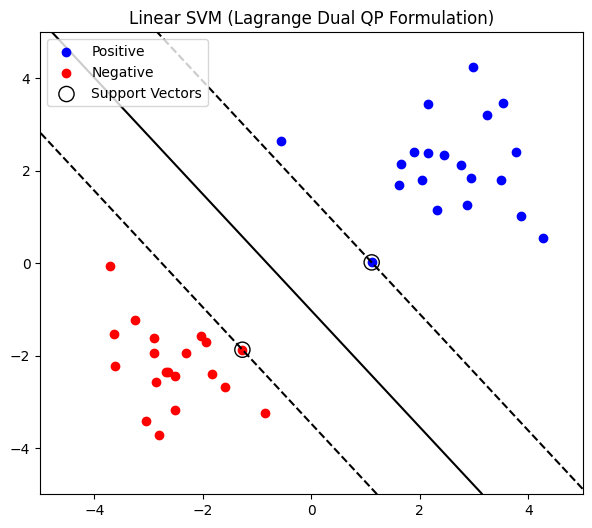

In [ ]:
import matplotlib.pyplot as plt

np.random.seed(0)
X_pos = np.random.randn(20, 2) + np.array([2, 2])
X_neg = np.random.randn(20, 2) + np.array([-2, -2])
X = np.vstack((X_pos, X_neg))
y = np.hstack((np.ones(20), -np.ones(20)))

svm = LinearHardMarginSVM()
svm.fit(X, y)

print("Weights:", svm.w)
print("Bias:", svm.b)

plt.figure(figsize=(7, 6))
plt.scatter(X_pos[:, 0], X_pos[:, 1], c='b', label='Positive')
plt.scatter(X_neg[:, 0], X_neg[:, 1], c='r', label='Negative')

plt.scatter(svm.support_vectors_[:, 0], svm.support_vectors_[:, 1],
            s=120, facecolors='none', edgecolors='k', label='Support Vectors')
xx = np.linspace(-5, 5, 50)
yy = np.linspace(-5, 5, 50)
YY, XX = np.meshgrid(yy, xx)
ZZ = svm.project(np.c_[XX.ravel(), YY.ravel()]).reshape(XX.shape)
plt.contour(XX, YY, ZZ, levels=[-1, 0, 1], linestyles=['--', '-', '--'], colors='k')

plt.legend()
plt.title("Linear SVM (Lagrange Dual QP Formulation)")
plt.show()

## **Kernel Trick**

If the classes are not **linearly separable** in the original feature space, a simple linear boundary cannot correctly divide them. However, it’s often possible that the same data become linearly separable in a higher-dimensional space,for instance, after being mapped into a 10,000-dimensional feature space.

The problem is that directly working in such a high-dimensional space would make the optimization extremely complex and computationally expensive. Moreover, classifying new data would require **computing dot products between very large vector**s, which is impractical.

Fortunately, there’s a powerful approach that allows us to achieve the same effect without explicitly transforming the data into higher dimensions. Before exploring this method, let’s examine the following example.

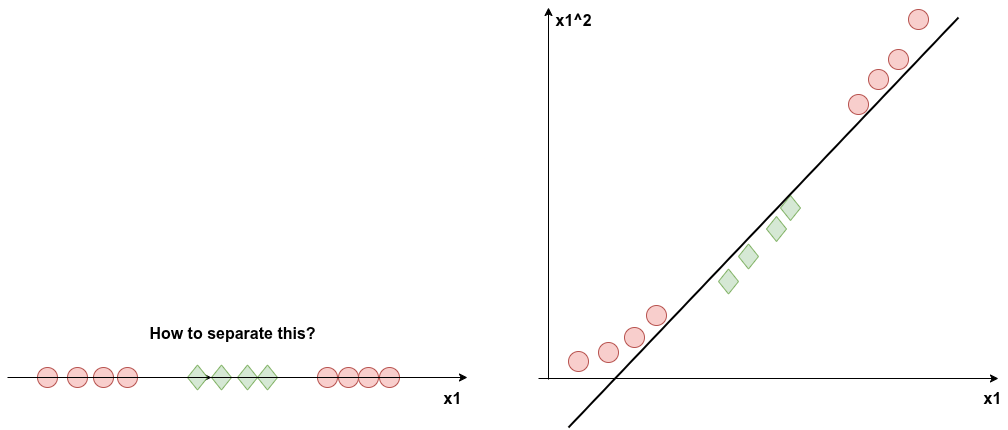

In the plot on the left, we have a single feature $x_1$ representing two classes (red circles and green diamonds). It is clear that these two classes are not linearly separable in this one-dimensional space, so a hard-margin SVM would fail to correctly classify the samples.

To address this, we can introduce a new feature derived from the existing one, for example, $x_1^2$. By doing so, we transform the data from a 1D space into a 2D feature space $(x_1, x_1^2)$. In this higher-dimensional space, the samples become separable, and the SVM can now find a linear decision boundary that effectively separates the two classes.

This approach illustrates the fundamental idea behind the **kernel trick** in SVMs: mapping data to a higher-dimensional space to make it linearly separable*.

Even though this approach works for the example above, there are many cases where simply taking powers of the features may not be sufficient to achieve linear separability. In more complex datasets, the relationships between features and classes can be highly nonlinear, and simple polynomial expansions might fail to capture the underlying structure.

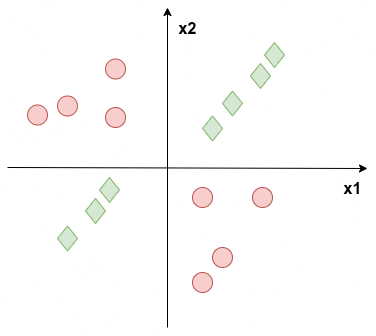

We need the method that must be applicable even when the original feature space is much higher than 2D. Additionally, after projecting the data into a higher-dimensional space, computing a linearly separating hyperplane requires taking **dot products** between high-dimensional vectors, which can quickly become computationally expensive.

Therefore, the algorithm needs to achieve two goals simultaneously:

1.   *we need the new features that map the samples into a higher-dimensional space where separation is possible*, and
2.  *we should avoid explicitly computing operations in that space while still determining the separating hyperplane*.

Consider a feature vector $\textbf{x}_1$ in **2-D** space. If we apply a mapping function $\phi: R^2 \rightarrow R^k$, where $k >>2$, the vector is transformed into a new vector $\phi(\textbf{x}_1) = \textbf{y}_1, \textbf{y}_1 \in R^k$ in **k-D** space. Computing the dot product between two vectors $\textbf{y}_1$ and $\textbf{y}_2$ in this high-dimensional space becomes significantly more computationally expensive than computing the dot product in the original **2-D** space.

To overcome this issue, we actually can find such **kernel function** $\textbf{K}$ which takes original vectors $\textbf{x}_1$ and $\textbf{x}_2$ and outputs ready-to-go dot product of these two vectors, but in higher dimensional **k-D** space:

$$
\textbf{K}(\textbf{x}_1, \textbf{x}_2) \rightarrow \textbf{y}_1 \cdot \textbf{y}_2.
$$

***With a kernel, the SVM only ever needs the dot products in that high-dimensional space, not the actual coordinates.**

***The kernel trick doesn’t literally “lift” the points into a higher-dimensional space. Instead, it lets the SVM act as if the points were in that higher-dimensional space by computing the relationships (dot products) between points as if they had been mapped. The entire trick is about replacing the dot product with a kernel function that implicitly encodes the high-dimensional relationships.**

In other words:

The SVM still works in the original space in terms of storing our data.

But the decision boundary it learns behaves as if the data were in a higher-dimensional space, because the kernel encodes those higher-dimensional relationships.

So, it’s all about geometry and relationships, not about explicitly creating extra features.

There are several types of **kernel** functions that can be used in. One common choice is the **polynomial kernel** defined as

$$
  \textbf{K}(\textbf{x}, \textbf{y}) = (c + \textbf{x} \cdot \textbf{y})^d,
$$

where $c$ and $d$ are some constant values.

For example, let $\textbf{x}_1=(x_1, y_1)$ and $\textbf{x}_2=(x_2, y_2)$. If we set constants as $c=2$ and $d=2$, then

\begin{align*}
\mathbf{K}(\mathbf{x}_1, \mathbf{x}_2)
&= (2 + \mathbf{x}_1 \cdot \mathbf{x}_2)^2 \\
&= (2 + x_1 x_2 + y_1 y_2)^2 \\
&= 4 + 4(x_1 x_2 + y_1 y_2) + (x_1 x_2 + y_1 y_2)^2 \\
&= 4 + 4 x_1 x_2 + 4 y_1 y_2 + x_1^2 x_2^2 + 2 x_1 x_2 y_1 y_2 + y_1^2 y_2^2
\end{align*}

This result is the same as if we firstly turn $\textbf{x}_1$ and $\textbf{x}_2$ into 6th dimensional vectors $\textbf{y}_1$ and  $\textbf{y}_2$:

$$
\mathbf{y}_1 = \phi(\mathbf{x}_1) =
\begin{bmatrix}
2 \\[1mm]
2 x_1 \\[1mm]
2 y_1 \\[1mm]
x_1^2 \\[1mm]
\sqrt{2}\, x_1 y_1 \\[1mm]
y_1^2
\end{bmatrix}, \quad
\mathbf{y}_2 = \phi(\mathbf{x}_2) =
\begin{bmatrix}
2 \\[1mm]
2 x_2 \\[1mm]
2 y_2 \\[1mm]
x_2^2 \\[1mm]
\sqrt{2}\, x_2 y_2 \\[1mm]
y_2^2
\end{bmatrix}
$$

Then the dot product in 6D space reproduces the kernel:

$$
\mathbf{y}_1 \cdot \mathbf{y}_2 = 4 + 4 x_1 x_2 + 4 y_1 y_2 + x_1^2 x_2^2 + 2 x_1 x_2 y_1 y_2 + y_1^2 y_2^2.
$$

The result shows that when we use a polynomial kernel with $c=2$ and $d=2$, the kernel function effectively computes the dot product in a higher-dimensional **6-D** feature space, but without ever explicitly constructing those higher-dimensional feature vectors.

The key insight is that the kernel trick allows us to compute the result of this dot product directly in the input space using the kernel formula, instead of explicitly mapping data into the higher-dimensional space and performing expensive calculations there.

In other words, the polynomial kernel acts as if we were working in a 6D space, capturing more complex relationships, while keeping computations efficient in the original 2D space.

The dimensionality of the feature space induced by the polynomial kernel

$$
K(\mathbf{x}, \mathbf{y}) = (c + \mathbf{x} \cdot \mathbf{y})^d
$$
is given by
$$
\text{Dim} = \sum_{k=0}^{d} \binom{n + k - 1}{k},
$$
where $ n $ is the dimensionality of the input space, and $ d $ is the degree of the polynomial.

For $ n = 2 $ and $ d = 2 $:
$$
\text{Dim} = \sum_{k=0}^{2} \binom{2 + k - 1}{k}
= \binom{1}{0} + \binom{2}{1} + \binom{3}{2}
= 1 + 2 + 3 = 6.
$$


The kernel function $\mathbf{K}$ is used during training in the **dual formulation** of the SVM.
The dual optimization problem is:

$$
\begin{aligned}
\max_{\boldsymbol{\alpha}} \quad &
\sum_{i=1}^{N} \alpha_i - \frac{1}{2} \sum_{i=1}^{N} \sum_{j=1}^{N} \alpha_i \alpha_j y_i y_j K(\mathbf{x}_i, \mathbf{x}_j) \\
\text{subject to} \quad &
\sum_{i=1}^{N} \alpha_i y_i = 0, \\
& \alpha_i \ge 0, \quad i = 1, \dots, N,
\end{aligned}
$$

where:

- $\alpha_i$ are the Lagrange multipliers,

- $y_i \in \{+1, -1\}$ are the class labels,

- $\mathbf{x}_i$ are the training samples, and

- $K(\mathbf{x}_i, \mathbf{x}_j)$ is the kernel function.

**Kernelized SVM Decision Function**

After training, the classification of a new sample $\mathbf{x}_{\text{new}}$ is performed using the kernel:

$$
f(\mathbf{x}_{\text{new}}) = \text{sign} \Bigg( \sum_{i \in \text{SV}} \alpha_i y_i K(\mathbf{x}_i, \mathbf{x}_{\text{new}}) + b \Bigg),
$$

where:


- $\mathbf{x}_i$ are the support vectors,

- $y_i \in \{+1, -1\}$ are their labels,

- $\alpha_i$ are the dual variables obtained from training, and

- $K(\mathbf{x}_i, \mathbf{x}_{\text{new}})$ is the kernel function.



The bias can be computed using any support vector $\mathbf{x}_s$:

$$
b = y_s - \sum_{i \in \text{SV}} \alpha_i y_i K(\mathbf{x}_i, \mathbf{x}_s),
$$

or more stably by averaging over all support vectors:

$$
b = \frac{1}{N_{\text{SV}}} \sum_{s \in \text{SV}} \left( y_s - \sum_{i \in \text{SV}} \alpha_i y_i K(\mathbf{x}_i, \mathbf{x}_s) \right).
$$

In addition to **polynomial kernel** there is other options like **radial kernel or radial basis function(RBF)**. This kernel works in the **infinite dimensions**. For one who is interested in this option, I recommend the next video tutorial: https://www.youtube.com/watch?v=Qc5IyLW_hns.

Now, let's look on the implementation. The kernel allows **SVM** to find complex decision boundaries without ever computing the high-dimensional coordinates explicitly.

That is why our XOR-like data becomes separable and you see curved decision boundaries in 2D. In 6th dimensional space **SVM** finds the separating hyperplane. The curved decision boundaries are the projection of the **single 6D hyperplane** onto the initial 2D feature space.

In [ ]:
class PolynomialKernelSVM:
    def __init__(self, degree=2, coef0=1, gamma=None):
        self.degree = degree
        self.coef0 = coef0
        self.gamma = gamma
        self.alphas = None
        self.support_vectors_ = None
        self.support_labels_ = None
        self.support_multipliers_ = None
        self.b = None

    def _polynomial_kernel(self, X1, X2):
        if self.gamma is None:
            self.gamma = 1.0 / X1.shape[1] if X1.shape[1] > 0 else 1.0
        return (self.gamma * np.dot(X1, X2.T) + self.coef0) ** self.degree

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        n_samples, n_features = X.shape

        K = self._polynomial_kernel(X, X)
        P = matrix(np.outer(y, y) * K)
        q = matrix(-np.ones(n_samples))
        G = matrix(-np.eye(n_samples))
        h = matrix(np.zeros(n_samples))
        A = matrix(y, (1, n_samples), 'd')
        b = matrix(0.0)

        solvers.options['show_progress'] = False
        solvers.options['abstol'] = 1e-12
        solvers.options['reltol'] = 1e-12
        sol = solvers.qp(P, q, G, h, A, b)

        alphas = np.ravel(sol['x'])

        sv_threshold = 1e-4
        sv = alphas > sv_threshold

        self.alphas = alphas
        self.support_vectors_ = X[sv]
        self.support_labels_ = y[sv]
        self.support_multipliers_ = alphas[sv]

        b_values = []

        for i in range(len(self.support_multipliers_)):
            kernel_vals = self._polynomial_kernel(self.support_vectors_,
                                                self.support_vectors_[i].reshape(1, -1))
            s = np.sum(self.support_multipliers_ * self.support_labels_ * kernel_vals.flatten())
            bias_candidate = self.support_labels_[i] - s

            predicted_margin = s + bias_candidate
            error = abs(predicted_margin - self.support_labels_[i])

            if error < 1e-8:  # Only use reliable bias calculations
                b_values.append(bias_candidate)

        if len(b_values) > 0:
            self.b = np.mean(b_values)
        else:
            for i in range(len(self.support_multipliers_)):
                kernel_vals = self._polynomial_kernel(self.support_vectors_,
                                                    self.support_vectors_[i].reshape(1, -1))
                s = np.sum(self.support_multipliers_ * self.support_labels_ * kernel_vals.flatten())
                b_values.append(self.support_labels_[i] - s)
            self.b = np.mean(b_values)

        return self

    def project(self, X):
        X = np.asarray(X, dtype=float)
        if self.support_vectors_ is None:
            return np.zeros(X.shape[0])
        K = self._polynomial_kernel(X, self.support_vectors_)
        return np.dot(K, self.support_multipliers_ * self.support_labels_) + self.b

    def predict(self, X):
        return np.sign(self.project(X))

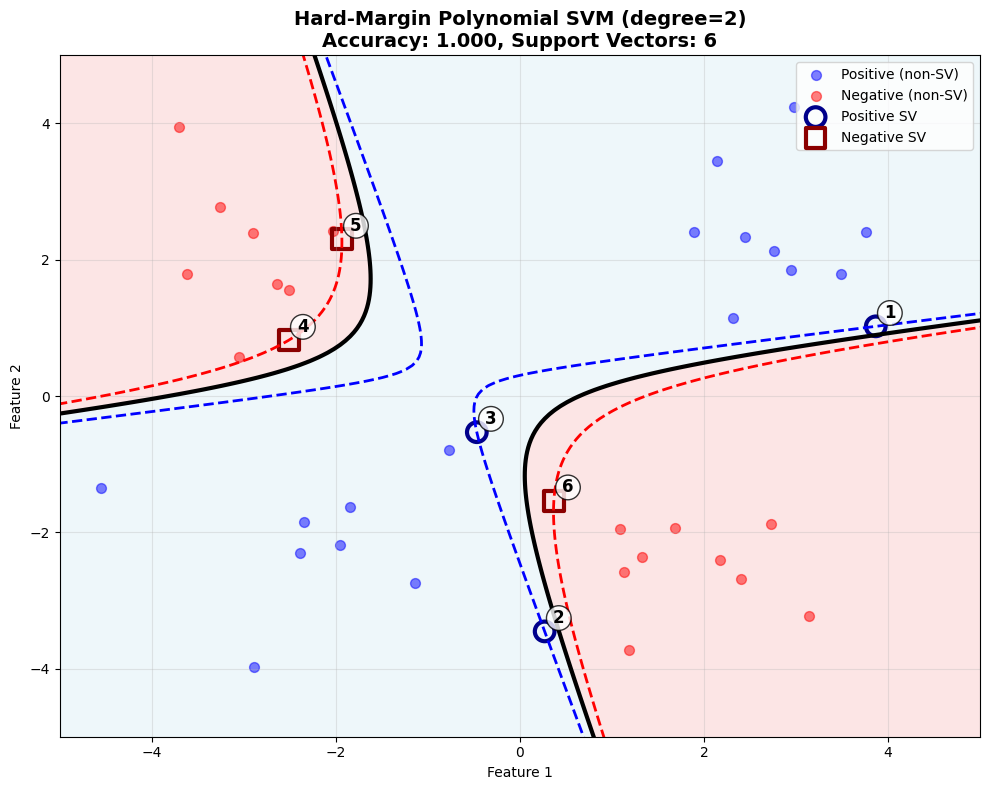

In [ ]:
np.random.seed(0)
X_pos = np.vstack([np.random.randn(10, 2) + [2, 2],
                   np.random.randn(10, 2) + [-2, -2]])
X_neg = np.vstack([np.random.randn(10, 2) + [-2, 2],
                   np.random.randn(10, 2) + [2, -2]])
X = np.vstack((X_pos, X_neg))
y = np.hstack((np.ones(20), -np.ones(20)))

degree = 2
svm = PolynomialKernelSVM(degree=degree, coef0=1, gamma=0.01)
svm.fit(X, y)

y_pred = svm.predict(X)
accuracy = np.mean(y_pred == y)

plt.figure(figsize=(10, 8))

xx = np.linspace(-6, 6, 200)
yy = np.linspace(-6, 6, 200)
YY, XX = np.meshgrid(yy, xx)
ZZ = svm.project(np.c_[XX.ravel(), YY.ravel()]).reshape(XX.shape)

plt.contourf(XX, YY, ZZ, levels=[-100, 0, 100],
             colors=['lightcoral', 'lightblue'], alpha=0.2)

non_sv_mask = np.ones(len(X), dtype=bool)
for sv in svm.support_vectors_:
    distances = np.linalg.norm(X - sv, axis=1)
    closest_idx = np.argmin(distances)
    non_sv_mask[closest_idx] = False

plt.scatter(X[non_sv_mask & (y==1), 0], X[non_sv_mask & (y==1), 1],
           c='blue', alpha=0.5, s=50, label='Positive (non-SV)')
plt.scatter(X[non_sv_mask & (y==-1), 0], X[non_sv_mask & (y==-1), 1],
           c='red', alpha=0.5, s=50, label='Negative (non-SV)')

pos_sv_plotted = False
neg_sv_plotted = False

for i, sv in enumerate(svm.support_vectors_):
    if svm.support_labels_[i] == 1:
        plt.scatter(sv[0], sv[1], s=200, facecolors='none',
                   edgecolors='darkblue', linewidth=3, marker='o',
                   label='Positive SV' if not pos_sv_plotted else "")
        pos_sv_plotted = True
    else:
        plt.scatter(sv[0], sv[1], s=200, facecolors='none',
                   edgecolors='darkred', linewidth=3, marker='s',
                   label='Negative SV' if not neg_sv_plotted else "")
        neg_sv_plotted = True

    plt.annotate(f'{i+1}', (sv[0], sv[1]),
                xytext=(6, 6), textcoords='offset points',
                fontsize=12, fontweight='bold',
                bbox=dict(boxstyle="circle,pad=0.2", facecolor='white', alpha=0.8))
plt.contour(XX, YY, ZZ, levels=[-1, 0, 1],
            linestyles=['--', '-', '--'], colors=['red', 'black', 'blue'],
            linewidths=[2, 3, 2])

plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.title(f"Hard-Margin Polynomial SVM (degree={degree})\nAccuracy: {accuracy:.3f}, Support Vectors: {len(svm.support_vectors_)}",
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

## **Soft Margin SVM**

For real-world data that may not be perfectly linearly separable, we introduce $\textbf{slack variables}$ $\xi_i \ge 0$ and a $\textbf{penalty parameter}$ $C > 0$. The soft-margin SVM solves:

$$
\begin{aligned}
\min_{\mathbf{w}, b, \boldsymbol{\xi}} \quad & \frac{1}{2} \|\mathbf{w}\|^2 + C \sum_{i=1}^N \xi_i \\
\text{subject to} \quad & y_i (\mathbf{w} \cdot \mathbf{x}_i + b) \ge 1 - \xi_i, \quad \forall i, \\
& \xi_i \ge 0, \quad \forall i.
\end{aligned}
$$

$\xi_i \ge 0$ are slack variables that allow samples to $\textbf{violate the margin}$:

- $\xi_i = 0$ : sample lies on or outside the margin

- $0 < \xi_i < 1$ : sample inside margin but correct side

- $\xi_i > 1$ : sample misclassified.

$C > 0$ is a regularization parameter controlling the trade-off between $\textbf{maximizing the margin}$ and $\textbf{allowing misclassification}$:

- Large $C$ → penalizes violations heavily → closer to hard-margin
- Small $C$ → allows more violations → smoother margin.

**Comparison with Hard-Margin SVM**:

$$
\begin{array}{l|l|l}
\text{Feature} & \text{Hard-Margin} & \text{Soft-Margin} \\ \hline
\text{Data separability} & \text{Perfectly separable} & \text{Can be non-separable / noisy} \\
\text{Constraint} & y_i(\mathbf{w}\cdot\mathbf{x}_i + b) \ge 1 & y_i(\mathbf{w}\cdot\mathbf{x}_i + b) \ge 1 - \xi_i \\
\text{Slack variables} & \text{Not used} & \text{Introduced} (\xi_i \ge 0) \\
\text{Objective} & \frac{1}{2}\|\mathbf{w}\|^2 & \frac{1}{2}\|\mathbf{w}\|^2 + C \sum_{i=1}^N \xi_i
\end{array}
$$

## **References**

1. [StatQuest pt1](https://www.youtube.com/watch?v=efR1C6CvhmE), [StatQuest pt2](https://www.youtube.com/watch?v=Toet3EiSFcM)
2. [SeranoAcademy](https://www.youtube.com/watch?v=Lpr__X8zuE8)
3. Nello Cristianini, John Shawe-Taylor. An Introduction to Support Vector Machines and Other Kernel-based Learning Methods. 2000
4. Bernhard Schölkopf & Alexander J. Smola. Learning with Kernels: Support Vector Machines, Regularization, Optimization, and Beyond.
5. Shigeo Abe. Support Vector Machines for Pattern Classification. 2010.
6. Lutz H. Hamel. Knowledge Discovery with Support Vector Machines. 2009.
7. Yunqian Ma & Guodong Guo. Support Vector Machines Applications. 2014